## Practice Lecture 18 - Training DNN
In this lab we will look at how to train Deep Neural Networks for classification and regression. \
Based on Chapter 11 from Aurelien Geron's book, Hands-on Machine Learning with Scikit-Learn Keras & Tensorflow.\
Original code examples from book in github [here](https://github.com/ageron/handson-ml2)

<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/dtrad/geoml_course/blob/master/Practice18_trainingDNN.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
</table>

In [5]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

try:
    # %tensorflow_version only exists in Colab.
    %tensorflow_version 2.x
except Exception:
    pass

# TensorFlow ≥2.0 is required
import tensorflow as tf
from tensorflow import keras
assert tf.__version__ >= "2.0"

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt


## Exercise 1: activation functions
Plot activation functions logit, relu and leaky-relu

In [6]:
z=np.arange(-5,5,0.1)

In [7]:
def logit(z):
    return 1 / (1 + np.exp(-z))

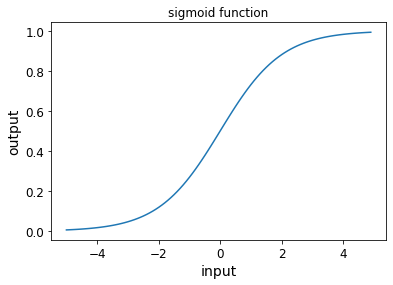

In [10]:
plt.figure()
plt.plot(z,logit(z))
plt.xlabel('input')
plt.ylabel('output')
plt.title('sigmoid function');

In [12]:
def leaky_relu(z, alpha=0.01):
    return np.maximum(alpha*z, z)

when Leaky Relu has coefficient $alpha=0$ it is the same as RELU

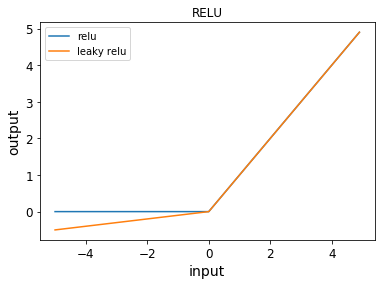

In [16]:
plt.plot(z,leaky_relu(z,0.0),label='relu')
plt.plot(z,leaky_relu(z,0.1),label='leaky relu')
plt.legend()
plt.xlabel('input')
plt.ylabel('output')
plt.title('RELU');

## Exercise 2: training for MNIST with different activation functions and initialization
Train a network for MNIST data using leaky_relu and compare with relu and sigmoid. Also compare two different initializations "he_init" and "zeros".\
For each case plot the loss and validations curves and evaluate on the test data.\
What does it work and what doesn't?

In [18]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.mnist.load_data()
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0
X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

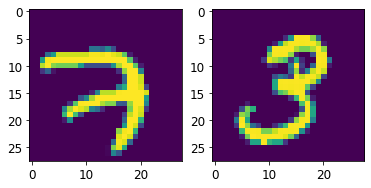

In [20]:
plt.figure()
plt.subplot(121);plt.imshow(X_train[0])
plt.subplot(122);plt.imshow(X_train[1]);


In [21]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, kernel_initializer="he_normal"),
    keras.layers.LeakyReLU(),
    keras.layers.Dense(100, kernel_initializer="he_normal"),
    keras.layers.LeakyReLU(),
    keras.layers.Dense(10, activation="softmax")
])

In [22]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(lr=1e-3),
              metrics=["accuracy"])

In [23]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten (Flatten)            (None, 784)               0         
_________________________________________________________________
dense (Dense)                (None, 300)               235500    
_________________________________________________________________
leaky_re_lu (LeakyReLU)      (None, 300)               0         
_________________________________________________________________
dense_1 (Dense)              (None, 100)               30100     
_________________________________________________________________
leaky_re_lu_1 (LeakyReLU)    (None, 100)               0         
_________________________________________________________________
dense_2 (Dense)              (None, 10)                1010      
Total params: 266,610
Trainable params: 266,610
Non-trainable params: 0
__________________________________________________

In [24]:
history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))

Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 4s 70us/sample - loss: 1.5155 - accuracy: 0.6216 - val_loss: 0.9224 - val_accuracy: 0.8082
Epoch 2/10
55000/55000 [==============================] - 3s 58us/sample - loss: 0.7324 - accuracy: 0.8307 - val_loss: 0.5774 - val_accuracy: 0.8610
Epoch 3/10
55000/55000 [==============================] - 3s 58us/sample - loss: 0.5351 - accuracy: 0.8618 - val_loss: 0.4629 - val_accuracy: 0.8792
Epoch 4/10
55000/55000 [==============================] - 3s 58us/sample - loss: 0.4560 - accuracy: 0.8777 - val_loss: 0.4066 - val_accuracy: 0.8914
Epoch 5/10
55000/55000 [==============================] - 3s 59us/sample - loss: 0.4124 - accuracy: 0.8862 - val_loss: 0.3730 - val_accuracy: 0.8984
Epoch 6/10
55000/55000 [==============================] - 3s 59us/sample - loss: 0.3840 - accuracy: 0.8924 - val_loss: 0.3491 - val_accuracy: 0.9052
Epoch 7/10
55000/55000 [==============================] -

In [25]:
model.evaluate(X_test,y_test)

10000/10000 [==============================] - 0s 48us/sample - loss: 0.3060 - accuracy: 0.9154


[0.3059845324397087, 0.9154]

In [26]:
history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

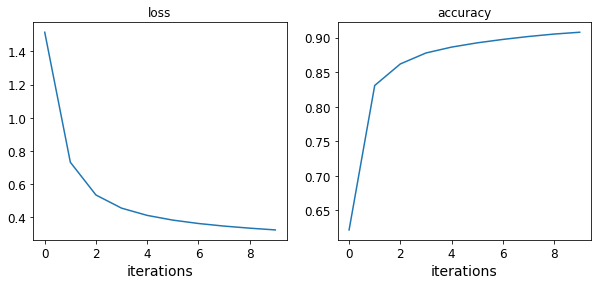

In [30]:
def plot_history(history):
    plt.figure(figsize=(10,4))
    plt.subplot(121);plt.plot(history.history["loss"])
    plt.xlabel('iterations')
    plt.title('loss')
    plt.subplot(122);plt.plot(history.history["accuracy"])
    plt.xlabel('iterations')
    plt.title('accuracy');
    
plot_history(history)

Let us compare with the standard RELU activation

In [32]:
model2 = keras.models.Sequential()
model2.add(keras.layers.Flatten(input_shape=[28,28]))
model2.add(keras.layers.Dense(300,activation="relu"))
model2.add(keras.layers.Dense(100,activation="relu"))
model2.add(keras.layers.Dense(10,activation="softmax"))

In [33]:
model2.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(lr=1e-3),
              metrics=["accuracy"])

In [34]:
model2.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_2 (Flatten)          (None, 784)               0         
_________________________________________________________________
dense_6 (Dense)              (None, 300)               235500    
_________________________________________________________________
dense_7 (Dense)              (None, 100)               30100     
_________________________________________________________________
dense_8 (Dense)              (None, 10)                1010      
Total params: 266,610
Trainable params: 266,610
Non-trainable params: 0
_________________________________________________________________


In [35]:
history2 = model2.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))

Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 4s 65us/sample - loss: 1.8032 - accuracy: 0.5279 - val_loss: 1.2505 - val_accuracy: 0.7598
Epoch 2/10
55000/55000 [==============================] - 3s 57us/sample - loss: 0.9469 - accuracy: 0.8069 - val_loss: 0.7042 - val_accuracy: 0.8506
Epoch 3/10
55000/55000 [==============================] - 3s 59us/sample - loss: 0.6206 - accuracy: 0.8573 - val_loss: 0.5222 - val_accuracy: 0.8748
Epoch 4/10
55000/55000 [==============================] - 3s 57us/sample - loss: 0.4978 - accuracy: 0.8740 - val_loss: 0.4407 - val_accuracy: 0.8896
Epoch 5/10
55000/55000 [==============================] - 3s 56us/sample - loss: 0.4361 - accuracy: 0.8843 - val_loss: 0.3951 - val_accuracy: 0.8978
Epoch 6/10
55000/55000 [==============================] - 3s 59us/sample - loss: 0.3986 - accuracy: 0.8918 - val_loss: 0.3643 - val_accuracy: 0.9058
Epoch 7/10
55000/55000 [==============================] -

In [36]:
model2.evaluate(X_test,y_test)

10000/10000 [==============================] - 0s 46us/sample - loss: 0.3065 - accuracy: 0.9131


[0.3064620155274868, 0.9131]

In [55]:
print(history.params)
print(history2.params)

{'batch_size': 32, 'epochs': 10, 'steps': 1719, 'samples': 55000, 'verbose': 0, 'do_validation': True, 'metrics': ['loss', 'accuracy', 'val_loss', 'val_accuracy']}
{'batch_size': 32, 'epochs': 10, 'steps': 1719, 'samples': 55000, 'verbose': 0, 'do_validation': True, 'metrics': ['loss', 'accuracy', 'val_loss', 'val_accuracy']}


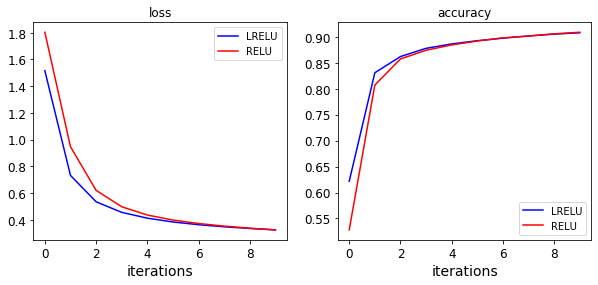

In [58]:
def plot_history(history, history2, case1, case2):
    niter=history.params['epochs']
    niter2=history.params['epochs']
    iter=np.arange(niter)
    iter2=np.arange(niter2)
    plt.figure(figsize=(10,4))
    plt.subplot(121);
    plt.plot(iter,history.history["loss"],'b-',label=case1);plt.plot(iter2,history2.history['loss'],'r-',label=case2)
    plt.xlabel('iterations')
    plt.title('loss')
    plt.legend()
    plt.subplot(122);
    plt.plot(iter,history.history["accuracy"],'b-',label=case1);plt.plot(iter2,history2.history['accuracy'],'r-',label=case2)
    plt.xlabel('iterations')
    plt.title('accuracy');
    plt.legend()
plot_history(history,history2,'LRELU','RELU')

We can see different activation functions implemented in Keras using dir(keras.activations)

In [61]:
[m for m in dir(keras.activations) if not m.startswith("_")]

['deserialize',
 'elu',
 'exponential',
 'get',
 'hard_sigmoid',
 'linear',
 'relu',
 'selu',
 'serialize',
 'sigmoid',
 'softmax',
 'softplus',
 'softsign',
 'tanh']

In [62]:
model3 = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, kernel_initializer="he_normal",activation="sigmoid"),
    keras.layers.Dense(100, kernel_initializer="he_normal",activation="sigmoid"),
    keras.layers.Dense(10, activation="softmax")
])
model3.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(lr=1e-3),
              metrics=["accuracy"])

In [63]:
history3 = model3.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))


Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 4s 65us/sample - loss: 2.3180 - accuracy: 0.1381 - val_loss: 2.2756 - val_accuracy: 0.1234
Epoch 2/10
55000/55000 [==============================] - 3s 57us/sample - loss: 2.2621 - accuracy: 0.2115 - val_loss: 2.2466 - val_accuracy: 0.2634
Epoch 3/10
55000/55000 [==============================] - 3s 57us/sample - loss: 2.2325 - accuracy: 0.3382 - val_loss: 2.2161 - val_accuracy: 0.3550
Epoch 4/10
55000/55000 [==============================] - 4s 64us/sample - loss: 2.2006 - accuracy: 0.4310 - val_loss: 2.1826 - val_accuracy: 0.4362
Epoch 5/10
55000/55000 [==============================] - 3s 58us/sample - loss: 2.1655 - accuracy: 0.5041 - val_loss: 2.1451 - val_accuracy: 0.5300
Epoch 6/10
55000/55000 [==============================] - 3s 57us/sample - loss: 2.1259 - accuracy: 0.5529 - val_loss: 2.1023 - val_accuracy: 0.5798
Epoch 7/10
55000/55000 [==============================] -

In [64]:
model3.evaluate(X_test,y_test)

10000/10000 [==============================] - 0s 45us/sample - loss: 1.8591 - accuracy: 0.6485


[1.8590885452270507, 0.6485]

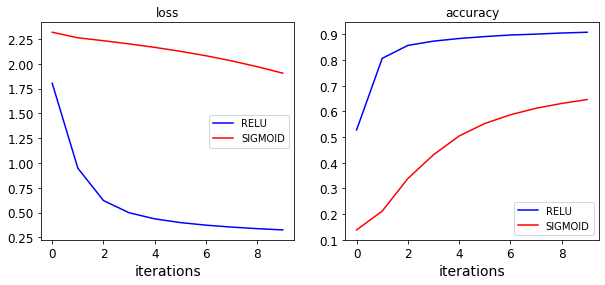

In [67]:
plot_history(history2,history3,'RELU','SIGMOID')

The same for initializers. We can check what is available by dir(keras.initializers)

In [68]:
[m for m in dir(keras.initializers) if not m.startswith("_")]

['Constant',
 'GlorotNormal',
 'GlorotUniform',
 'Identity',
 'Initializer',
 'Ones',
 'Orthogonal',
 'RandomNormal',
 'RandomUniform',
 'TruncatedNormal',
 'VarianceScaling',
 'Zeros',
 'constant',
 'deserialize',
 'get',
 'glorot_normal',
 'glorot_uniform',
 'he_normal',
 'he_uniform',
 'identity',
 'lecun_normal',
 'lecun_uniform',
 'ones',
 'orthogonal',
 'serialize',
 'zeros']

In [69]:
model4 = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, kernel_initializer="zeros",activation="sigmoid"),
    keras.layers.Dense(100, kernel_initializer="zeros",activation="sigmoid"),
    keras.layers.Dense(10, activation="softmax")
])
model4.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(lr=1e-3),
              metrics=["accuracy"])
history4 = model4.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))
model4.evaluate(X_test,y_test)

Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 4s 65us/sample - loss: 2.3198 - accuracy: 0.1065 - val_loss: 2.3007 - val_accuracy: 0.1126
Epoch 2/10
55000/55000 [==============================] - 3s 57us/sample - loss: 2.3014 - accuracy: 0.1123 - val_loss: 2.3003 - val_accuracy: 0.1126
Epoch 3/10
55000/55000 [==============================] - 3s 58us/sample - loss: 2.3014 - accuracy: 0.1123 - val_loss: 2.3011 - val_accuracy: 0.1126
Epoch 4/10
55000/55000 [==============================] - 3s 58us/sample - loss: 2.3013 - accuracy: 0.1122 - val_loss: 2.3007 - val_accuracy: 0.1126
Epoch 5/10
55000/55000 [==============================] - 3s 59us/sample - loss: 2.3013 - accuracy: 0.1123 - val_loss: 2.3006 - val_accuracy: 0.1126
Epoch 6/10
55000/55000 [==============================] - 3s 58us/sample - loss: 2.3012 - accuracy: 0.1125 - val_loss: 2.3002 - val_accuracy: 0.1126
Epoch 7/10
55000/55000 [==============================] -

[2.300752411651611, 0.1135]

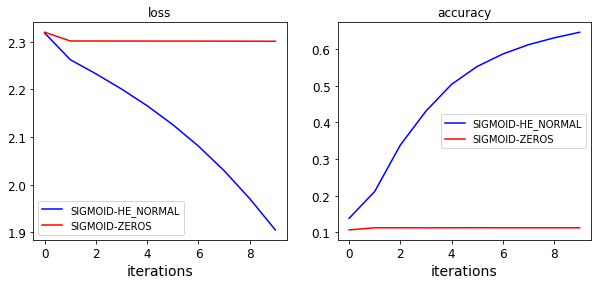

In [70]:
plot_history(history3,history4,'SIGMOID-HE_NORMAL','SIGMOID-ZEROS')

## Exercise 3: 
Use the first model with/without batch normalization. Plot the loss and accuracy curves for training and validation. Do you see any difference?
How many more parameters you need to optimize and why?

In [17]:
model5 = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(300, kernel_initializer="he_normal"),
    keras.layers.LeakyReLU(),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(100, kernel_initializer="he_normal"),
    keras.layers.LeakyReLU(),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(10, activation="softmax")
])

In [18]:
model5.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_2 (Flatten)          (None, 784)               0         
_________________________________________________________________
batch_normalization (BatchNo (None, 784)               3136      
_________________________________________________________________
dense_3 (Dense)              (None, 300)               235500    
_________________________________________________________________
leaky_re_lu_2 (LeakyReLU)    (None, 300)               0         
_________________________________________________________________
batch_normalization_1 (Batch (None, 300)               1200      
_________________________________________________________________
dense_4 (Dense)              (None, 100)               30100     
_________________________________________________________________
leaky_re_lu_3 (LeakyReLU)    (None, 100)              

In [19]:
model5.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(lr=1e-3),
              metrics=["accuracy"])
history5 = model5.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))
model5.evaluate(X_test,y_test)

Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 6s 108us/sample - loss: 0.8984 - accuracy: 0.7215 - val_loss: 0.4997 - val_accuracy: 0.8554
Epoch 2/10
55000/55000 [==============================] - 5s 94us/sample - loss: 0.4810 - accuracy: 0.8594 - val_loss: 0.3907 - val_accuracy: 0.8870
Epoch 3/10
55000/55000 [==============================] - 5s 94us/sample - loss: 0.4096 - accuracy: 0.8808 - val_loss: 0.3424 - val_accuracy: 0.9004
Epoch 4/10
55000/55000 [==============================] - 5s 94us/sample - loss: 0.3701 - accuracy: 0.8913 - val_loss: 0.3118 - val_accuracy: 0.9080
Epoch 5/10
55000/55000 [==============================] - 5s 94us/sample - loss: 0.3439 - accuracy: 0.8988 - val_loss: 0.2915 - val_accuracy: 0.9152
Epoch 6/10
55000/55000 [==============================] - 5s 94us/sample - loss: 0.3244 - accuracy: 0.9053 - val_loss: 0.2753 - val_accuracy: 0.9196
Epoch 7/10
55000/55000 [==============================] 

[0.23966434186697005, 0.9311]

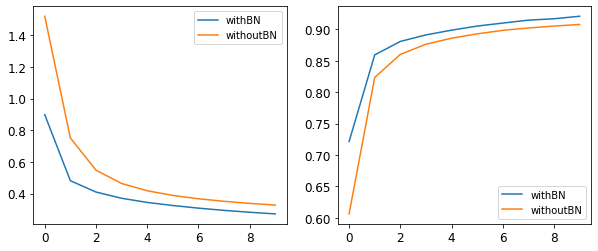

In [27]:
plt.figure(figsize=(10,4))
plt.subplot(121);plt.plot(history5.history["loss"],label="withBN");plt.plot(history.history["loss"],label="withoutBN");plt.legend()
plt.subplot(122);plt.plot(history5.history["accuracy"],label="withBN");plt.plot(history.history["accuracy"],label="withoutBN");plt.legend()

## Exercise 4
Load the fashion_mnist model as shown below and train it to do multiclass classification as shown on the book's notebook.
Remove classes 8 and 9. 
Then take only two items from the set and use it for binary classification. Instead of training the network from scratch, start from the network trained for the full data set. Replace the last layer for a sigmoid (softmax, i.e. multiclass, to sigmoid, binary classification). 

In [200]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0
X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

In [204]:
def split_dataset(X, y):
    y_8_or_9 = (y == 8) | (y == 9) # sandals or shirts
    y_A = y[~y_8_or_9]    
    y_B = (y[y_8_or_9] == 9).astype(np.float32) # binary classification task
    return ((X[~y_8_or_9], y_A),
            (X[y_8_or_9], y_B))

(X_train_A, y_train_A), (X_train_B, y_train_B) = split_dataset(X_train, y_train)
(X_valid_A, y_valid_A), (X_valid_B, y_valid_B) = split_dataset(X_valid, y_valid)
(X_test_A, y_test_A), (X_test_B, y_test_B) = split_dataset(X_test, y_test)
X_train_B = X_train_B[:200]
y_train_B = y_train_B[:200]

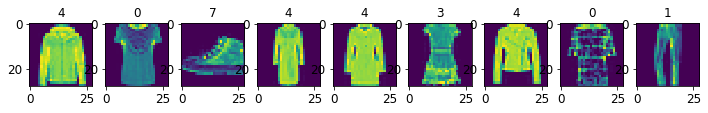

In [205]:
plt.figure(figsize=(12,6))
for i in range(9):    
    plt.subplot(191+i)
    plt.imshow(X_train_A[i]);plt.title(y_train_A[i])

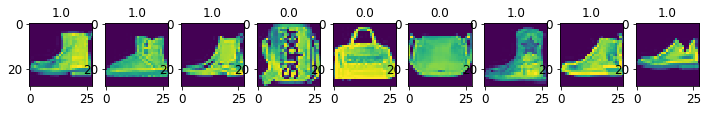

In [206]:
plt.figure(figsize=(12,6))
for i in range(9):    
    plt.subplot(191+i)
    plt.imshow(X_train_B[i]);plt.title(y_train_B[i])

In [207]:
tf.random.set_seed(42)
np.random.seed(42)

In [208]:
model_A = keras.models.Sequential()
model_A.add(keras.layers.Flatten(input_shape=[28, 28]))
for n_hidden in (300, 100, 50, 50, 50):
    model_A.add(keras.layers.Dense(n_hidden, activation="selu"))
model_A.add(keras.layers.Dense(8, activation="softmax"))

In [210]:
model_A.compile(loss="sparse_categorical_crossentropy",
                optimizer=keras.optimizers.SGD(lr=1e-3),
                metrics=["accuracy"])
model_A.fit(X_train_A,y_train_A,validation_data=(X_valid_A,y_valid_A),epochs=10)

Train on 43996 samples, validate on 4004 samples
Epoch 1/10
43996/43996 [==============================] - 4s 82us/sample - loss: 0.5008 - accuracy: 0.8163 - val_loss: 0.4765 - val_accuracy: 0.8292
Epoch 2/10
43996/43996 [==============================] - 3s 67us/sample - loss: 0.4740 - accuracy: 0.8267 - val_loss: 0.4581 - val_accuracy: 0.8337
Epoch 3/10
43996/43996 [==============================] - 3s 67us/sample - loss: 0.4554 - accuracy: 0.8334 - val_loss: 0.4490 - val_accuracy: 0.8314
Epoch 4/10
43996/43996 [==============================] - 3s 67us/sample - loss: 0.4411 - accuracy: 0.8381 - val_loss: 0.4349 - val_accuracy: 0.8427
Epoch 5/10
43996/43996 [==============================] - 3s 67us/sample - loss: 0.4294 - accuracy: 0.8418 - val_loss: 0.4333 - val_accuracy: 0.8419
Epoch 6/10
43996/43996 [==============================] - 3s 67us/sample - loss: 0.4206 - accuracy: 0.8467 - val_loss: 0.4232 - val_accuracy: 0.8424
Epoch 7/10
43996/43996 [==============================] -

In [211]:
model_A.summary()

Model: "sequential_18"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_10 (Flatten)         (None, 784)               0         
_________________________________________________________________
dense_62 (Dense)             (None, 300)               235500    
_________________________________________________________________
dense_63 (Dense)             (None, 100)               30100     
_________________________________________________________________
dense_64 (Dense)             (None, 50)                5050      
_________________________________________________________________
dense_65 (Dense)             (None, 50)                2550      
_________________________________________________________________
dense_66 (Dense)             (None, 50)                2550      
_________________________________________________________________
dense_67 (Dense)             (None, 8)               

In [212]:
model_A.save("my_model_A.h5")

In [213]:
model_A = keras.models.load_model("my_model_A.h5")
model_B_on_A = keras.models.Sequential(model_A.layers[:-1])
model_B_on_A.add(keras.layers.Dense(1, activation="sigmoid"))

In [214]:
for layer in model_B_on_A.layers[:-1]:
    layer.trainable = False

model_B_on_A.compile(loss="binary_crossentropy",
                     optimizer=keras.optimizers.SGD(lr=1e-3),
                     metrics=["accuracy"])

In [215]:
model_B_on_A.summary()

Model: "sequential_19"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_10 (Flatten)         (None, 784)               0         
_________________________________________________________________
dense_62 (Dense)             (None, 300)               235500    
_________________________________________________________________
dense_63 (Dense)             (None, 100)               30100     
_________________________________________________________________
dense_64 (Dense)             (None, 50)                5050      
_________________________________________________________________
dense_65 (Dense)             (None, 50)                2550      
_________________________________________________________________
dense_66 (Dense)             (None, 50)                2550      
_________________________________________________________________
dense_68 (Dense)             (None, 1)               

New data set with the same format as MNIST

In [216]:
model_A.evaluate(X_test_A, y_test_A)

8000/8000 [==============================] - 0s 62us/sample - loss: 0.4492 - accuracy: 0.8336


[0.44919588428735735, 0.833625]

In [217]:
model_B_on_A.evaluate(X_test_B, y_test_B)

2000/2000 [==============================] - 0s 116us/sample - loss: 1.4864 - accuracy: 0.3785


[1.4863513422012329, 0.3785]

In [218]:
history = model_B_on_A.fit(X_train_B, y_train_B, epochs=4,
                           validation_data=(X_valid_B, y_valid_B))
model_B_on_A.evaluate(X_test_B, y_test_B)

Train on 200 samples, validate on 996 samples
Epoch 1/4
200/200 [==============================] - 0s 2ms/sample - loss: 1.4537 - accuracy: 0.3800 - val_loss: 1.4458 - val_accuracy: 0.3755
Epoch 2/4
200/200 [==============================] - 0s 414us/sample - loss: 1.3797 - accuracy: 0.3850 - val_loss: 1.3705 - val_accuracy: 0.3745
Epoch 3/4
200/200 [==============================] - 0s 411us/sample - loss: 1.3081 - accuracy: 0.3800 - val_loss: 1.2944 - val_accuracy: 0.3735
Epoch 4/4
2000/2000 [==============================] - 0s 48us/sample - loss: 1.1966 - accuracy: 0.3795


[1.1966171236038208, 0.3795]

In [219]:
for layer in model_B_on_A.layers[:-1]:
    layer.trainable = True

model_B_on_A.compile(loss="binary_crossentropy",
                     optimizer=keras.optimizers.SGD(lr=1e-3),
                     metrics=["accuracy"])
history = model_B_on_A.fit(X_train_B, y_train_B, epochs=16,
                           validation_data=(X_valid_B, y_valid_B))
model_B_on_A.evaluate(X_test_B, y_test_B)

Train on 200 samples, validate on 996 samples
Epoch 1/16
200/200 [==============================] - 1s 3ms/sample - loss: 1.0479 - accuracy: 0.3750 - val_loss: 0.8823 - val_accuracy: 0.4167
Epoch 2/16
200/200 [==============================] - 0s 462us/sample - loss: 0.7624 - accuracy: 0.4800 - val_loss: 0.6657 - val_accuracy: 0.5924
Epoch 3/16
200/200 [==============================] - 0s 422us/sample - loss: 0.5725 - accuracy: 0.7100 - val_loss: 0.5225 - val_accuracy: 0.8102
Epoch 4/16
200/200 [==============================] - 0s 406us/sample - loss: 0.4515 - accuracy: 0.8600 - val_loss: 0.4345 - val_accuracy: 0.8785
Epoch 5/16
200/200 [==============================] - 0s 407us/sample - loss: 0.3739 - accuracy: 0.9300 - val_loss: 0.3670 - val_accuracy: 0.9297
Epoch 6/16
200/200 [==============================] - 0s 406us/sample - loss: 0.3166 - accuracy: 0.9750 - val_loss: 0.3250 - val_accuracy: 0.9438
Epoch 7/16
200/200 [==============================] - 0s 408us/sample - loss: 0.

[0.13717768716812134, 0.979]